In [2]:
# load needed python libraries matplotlib, numpy, and scikit-rf
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf
import json
from scipy.optimize import curve_fit

In [2]:
data = rf.read_all('ampdata')
#fghz = data1['trace0'].f/1e9
fghz = data['trace0'].f/1e9

In [1]:
def lorentzian(x,x0,curvepeak,fwhm):
    return curvepeak/(1 + 4*((x-x0)/(fwhm))**2)
graw = np.abs(data['trace50'].s[:,0,0])**2
f = fghz
plt.subplots(figsize=(20,10))
plt.plot(fghz,graw,'.')
popt, pcov = curve_fit(lorentzian,fghz,graw,p0=(6.5,80,0.03))

plt.plot(fghz,lorentzian(fghz,popt[0],popt[1],popt[2]))
plt.xlim(fghz.min(),fghz.max())
plt.vlines(popt[0],0,100)
plt.vlines(popt[0] - 0.5*popt[2],0,100)
plt.vlines(popt[0] + 0.5*popt[2],0,100)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Linear Power Gain')
plt.grid()
popt

f0 = popt[0]
fwhm = popt[1]
curvepeak = 10*np.log10(popt[2])
gaindb = 10*np.log10(graw)
gaindbfit = 10*np.log10(lorentzian(fghz,f0,fwhm,curvepeak))

tracedata = {}
tracedata['fghz'] = fghz.tolist()
tracedata['gaindb'] = gaindb.tolist()
tracedata['gaindbfit'] = gaindbfit.tolist()
tracedata['f0'] = popt[0]
tracedata['fwhm'] = popt[1]
tracedata['curvepeak'] = popt[2]
file_object = open("tracedata.json", "w")
json_string = file_object.write(json.dumps(tracedata))
file_object.close()

NameError: name 'np' is not defined

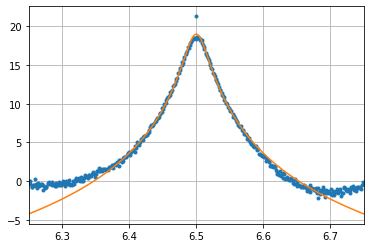

In [4]:
plt.plot(fghz,gaindb,'.')
plt.plot(fghz,gaindbfit)
plt.xlim(f.min(),f.max())
plt.grid()


In [5]:
tracedata = {}
tracedata['fghz'] = fghz.tolist()
tracedata['gaindb'] = gaindb.tolist()
tracedata['gaindbfit'] = gaindbfit.tolist()
tracedata['f0'] = popt[0]
tracedata['fwhm'] = popt[1]
tracedata['curvepeak'] = popt[2]
file_object = open("tracedata.json", "w")
json_string = file_object.write(json.dumps(tracedata))
file_object.close()